Plots measuring the circulation of the vortex rings.

Plots that will be shown:

* injection length against circulation
* velocity against circulation - if I have good results for this.
* for the same injection conditions varying the rotation rate
* peak circulation vs rotation rate
* peak circulaiton vs time to peak
* peak vorticity against time
* vertical and horizontal sums of circulation to show density in comparison to peak vorticcity against time

Circulation calculated is 1D $\therefore$ I can add the second dimension of the number of cases

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()


h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')

vels = h5file['Narrow']['U50']['L50']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
u, v = u/0.1, v/0.1 
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
Time = oj.frames_to_seconds(u, v, 90)
# h5file.close()

Circulation = np.zeros([7, u.shape[0]])
# Circulation = np.zeros([u.shape[0]])

rpms = [0, 1, 2, 3, 6, 9, 12]
Eks = ['infinity', 0.0000102, 0.0000051, 0.0000034, 0.0000017, 0.0000011, 0.00000085]

for i in range(len(rpms)):
# for i in range(3):
    # vels = h5file['Narrow']['U50']['L50']['RPM{}'.format(rpms[i])]
    vels = h5file['Narrow']['U50']['L50'][f'RPM{rpms[i]}']
    # vels = h5file['Narrow']['U100']['L100']['RPM0']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90)
    Circulation[i, :] = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])
    # Circulation = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])
    print(rpms[i])

Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

C:/Coding
Thesis plot settings applied
0
1
2
3
6
9
12


Create the plot for different rotation rates:

5050 gives the best result i would say

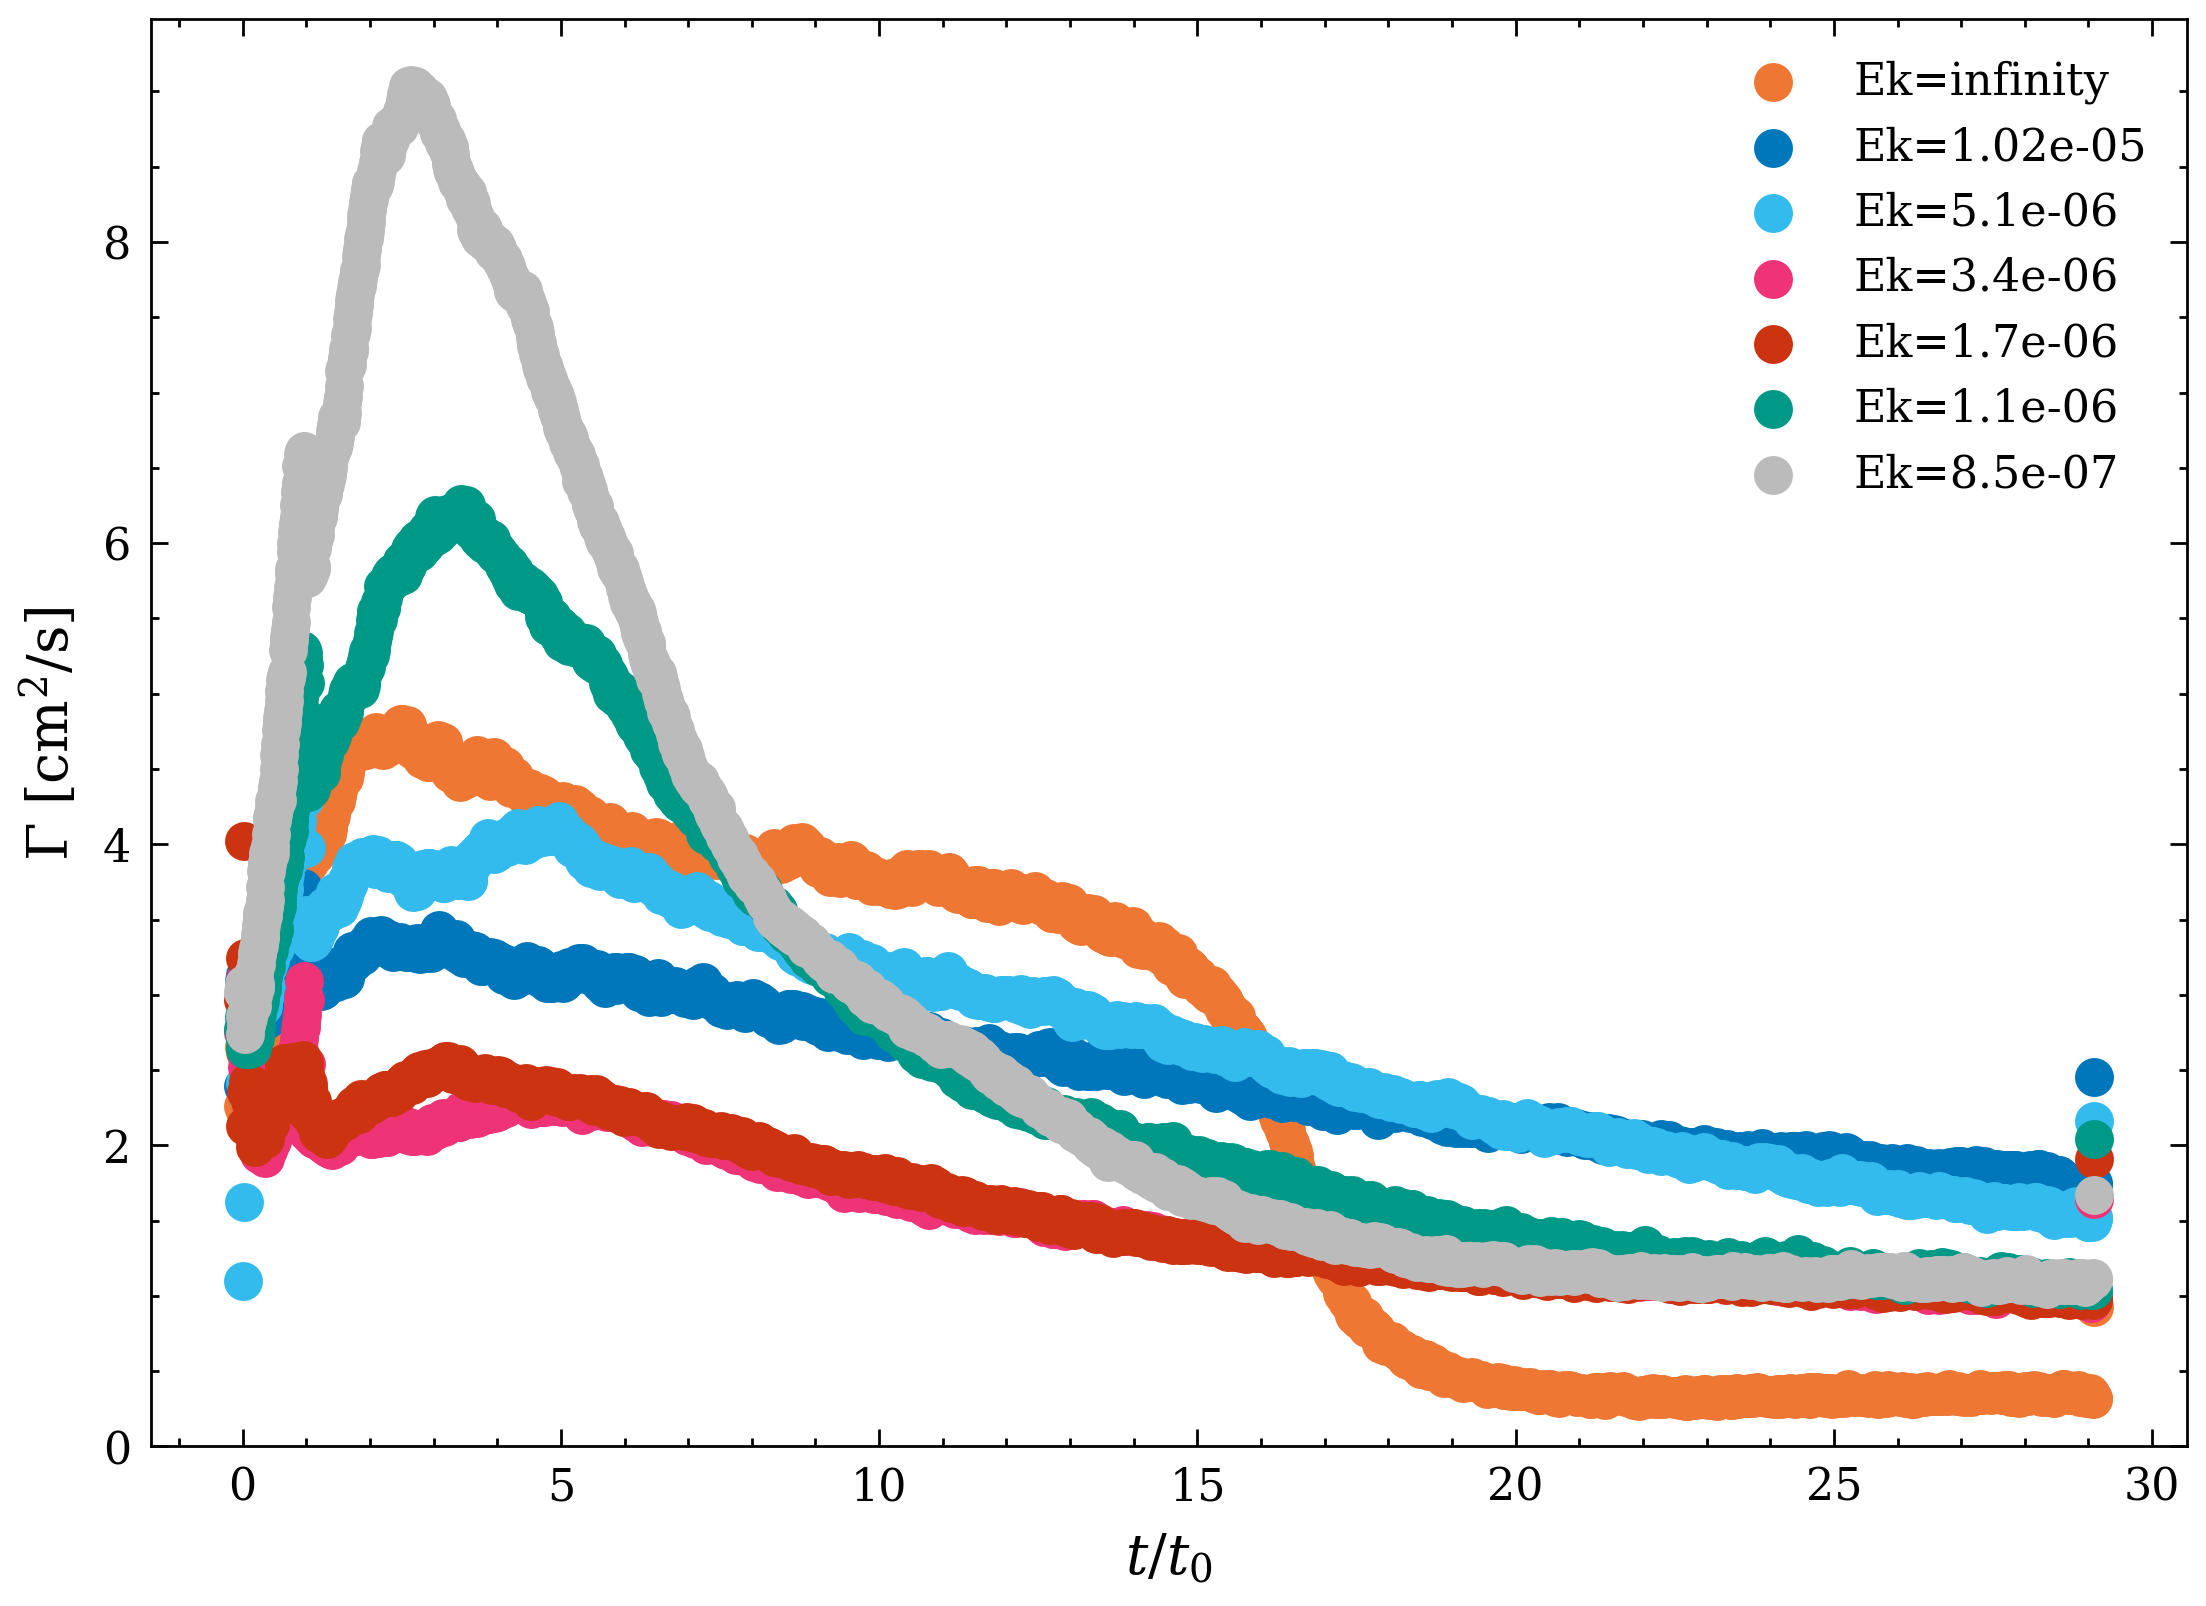

In [25]:
start_frame = 81
end_frame = 1891

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4))

for i in range(7):
    # ax.scatter(Time[start_frame:end_frame]-8/9, Circulation[i, start_frame:end_frame], label='Ek={}'.format(Eks[i]))
    ax.scatter(Time[start_frame:]-8/9, Circulation[i, start_frame:]-1, label='Ek={}'.format(Eks[i]))
    # ax.plot(Circulation[i, start_frame:end_frame], label='{} RPM'.format(rpms[i]))
# ax.plot(sumVorticity5050[:], label='{} RPM'.format(rpms[i]))
# ax.plot(Circulation[:], label='{} RPM'.format(rpms[i]))
ax.set_xlabel(r'$t/t_{0}$')
ax.set_ylabel(r'$\Gamma$ [cm$^2$/s]')
ax.legend(fontsize=8)
ax.set_ylim(0)
plt.show()

For different rotation rates, plot the peak circulation, and the time to peak circulation.

this doesn't work in ekman for the non-rotating case obviously.

Plots:
* Peak $\Gamma$ against time
* Time to peak $\Gamma$ against ro - I can then do it for other conditions

$\Omega = rpm/60 \times 2 \times \Pi$

0.19272315135762316
0.10663731541871764
0.07371168224916111
0.03826617312159579
0.02584038631312619
0.01950630233179319


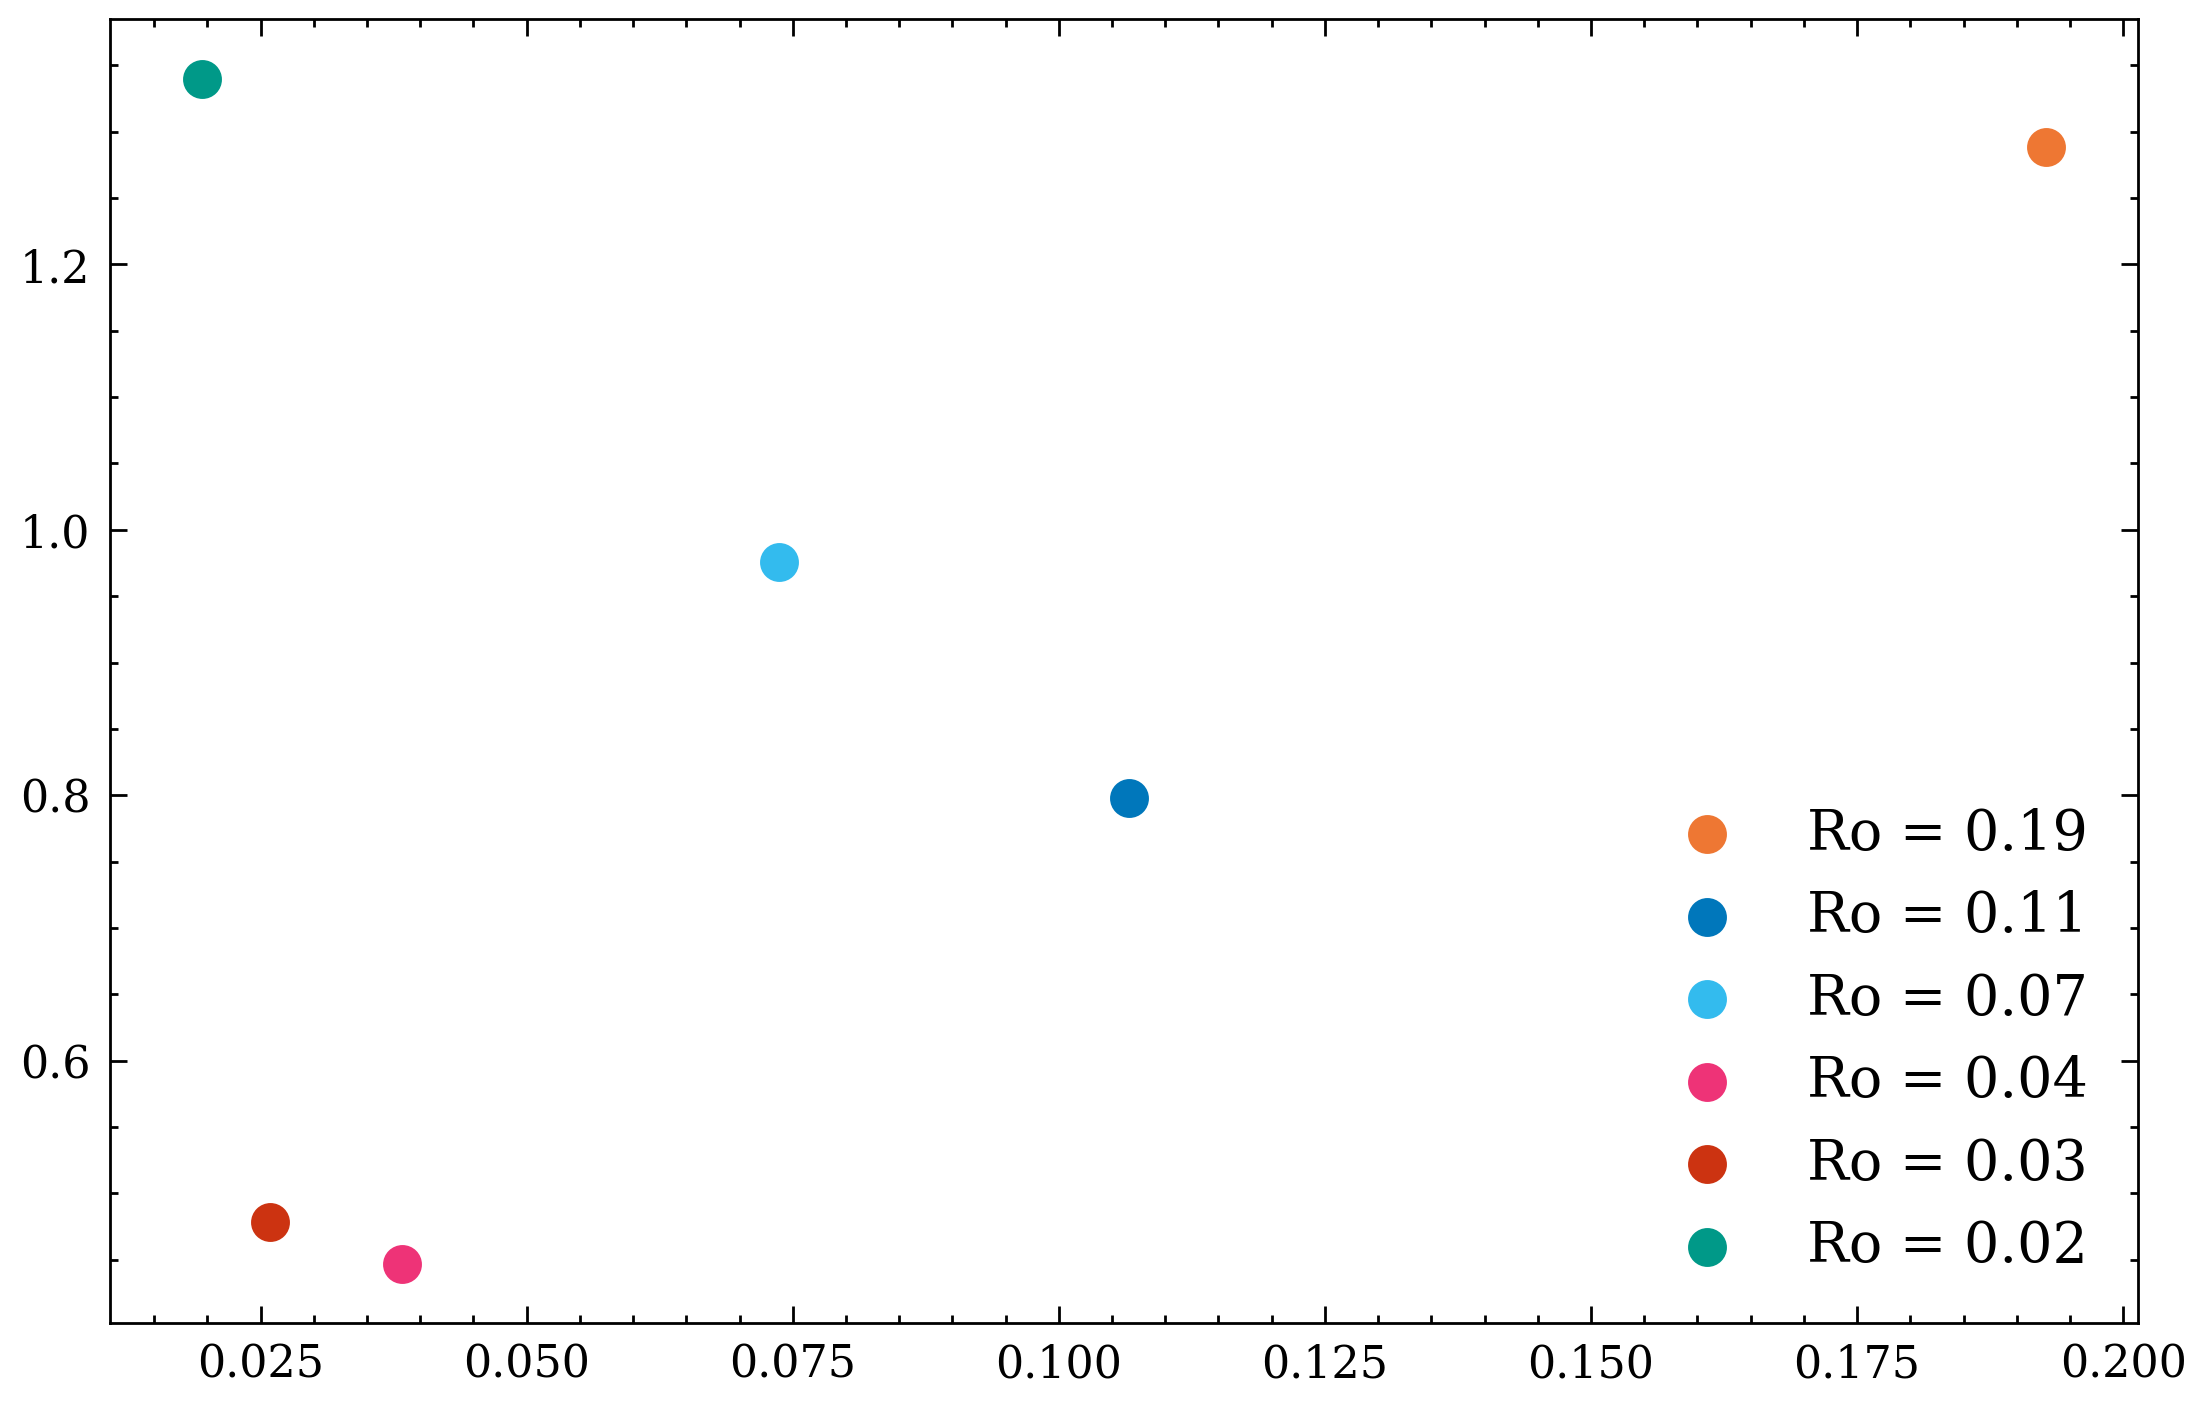

In [ ]:
revs = [1, 2, 3, 6, 9, 12]
Rossby = np.zeros([7])
u0 = 0.05

for i in range(6):
    Rossby[i] = u0 / (2 * revs[i]/60 * 2*np.pi + 0.05)
    print(Rossby[i])


fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))
# ax.scatter(0, Circulation[0,200], label=r'Ro = $\infty$', marker='x')
for i in range(6):
    ax.scatter(Rossby[i], ([Circulation[i,200]]), label='Ro = {}'.format(round(Rossby[i], 2)))

plt.legend(fontsize=8)

Different Injection lengths:

In [8]:
# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
h5file = h5py.File('E:/H5/LengthTest.h5', 'r')

# lens = [50, 100]
lens = [25, 50, 75, 100, 125, 150, 175, 200, 225, 240]
Circulation = np.zeros([len(lens), u.shape[0]])


for i in range(len(lens)):
    print(lens[i])
    vels = h5file['Narrow']['U100']['L{}'.format(lens[i])]['RPM0']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90)
    Circulation[i, :] = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])
    # Circulation = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])

Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

25
50
75
100
125
150
175
200
225
240


IndexError: index 7 is out of bounds for axis 0 with size 7

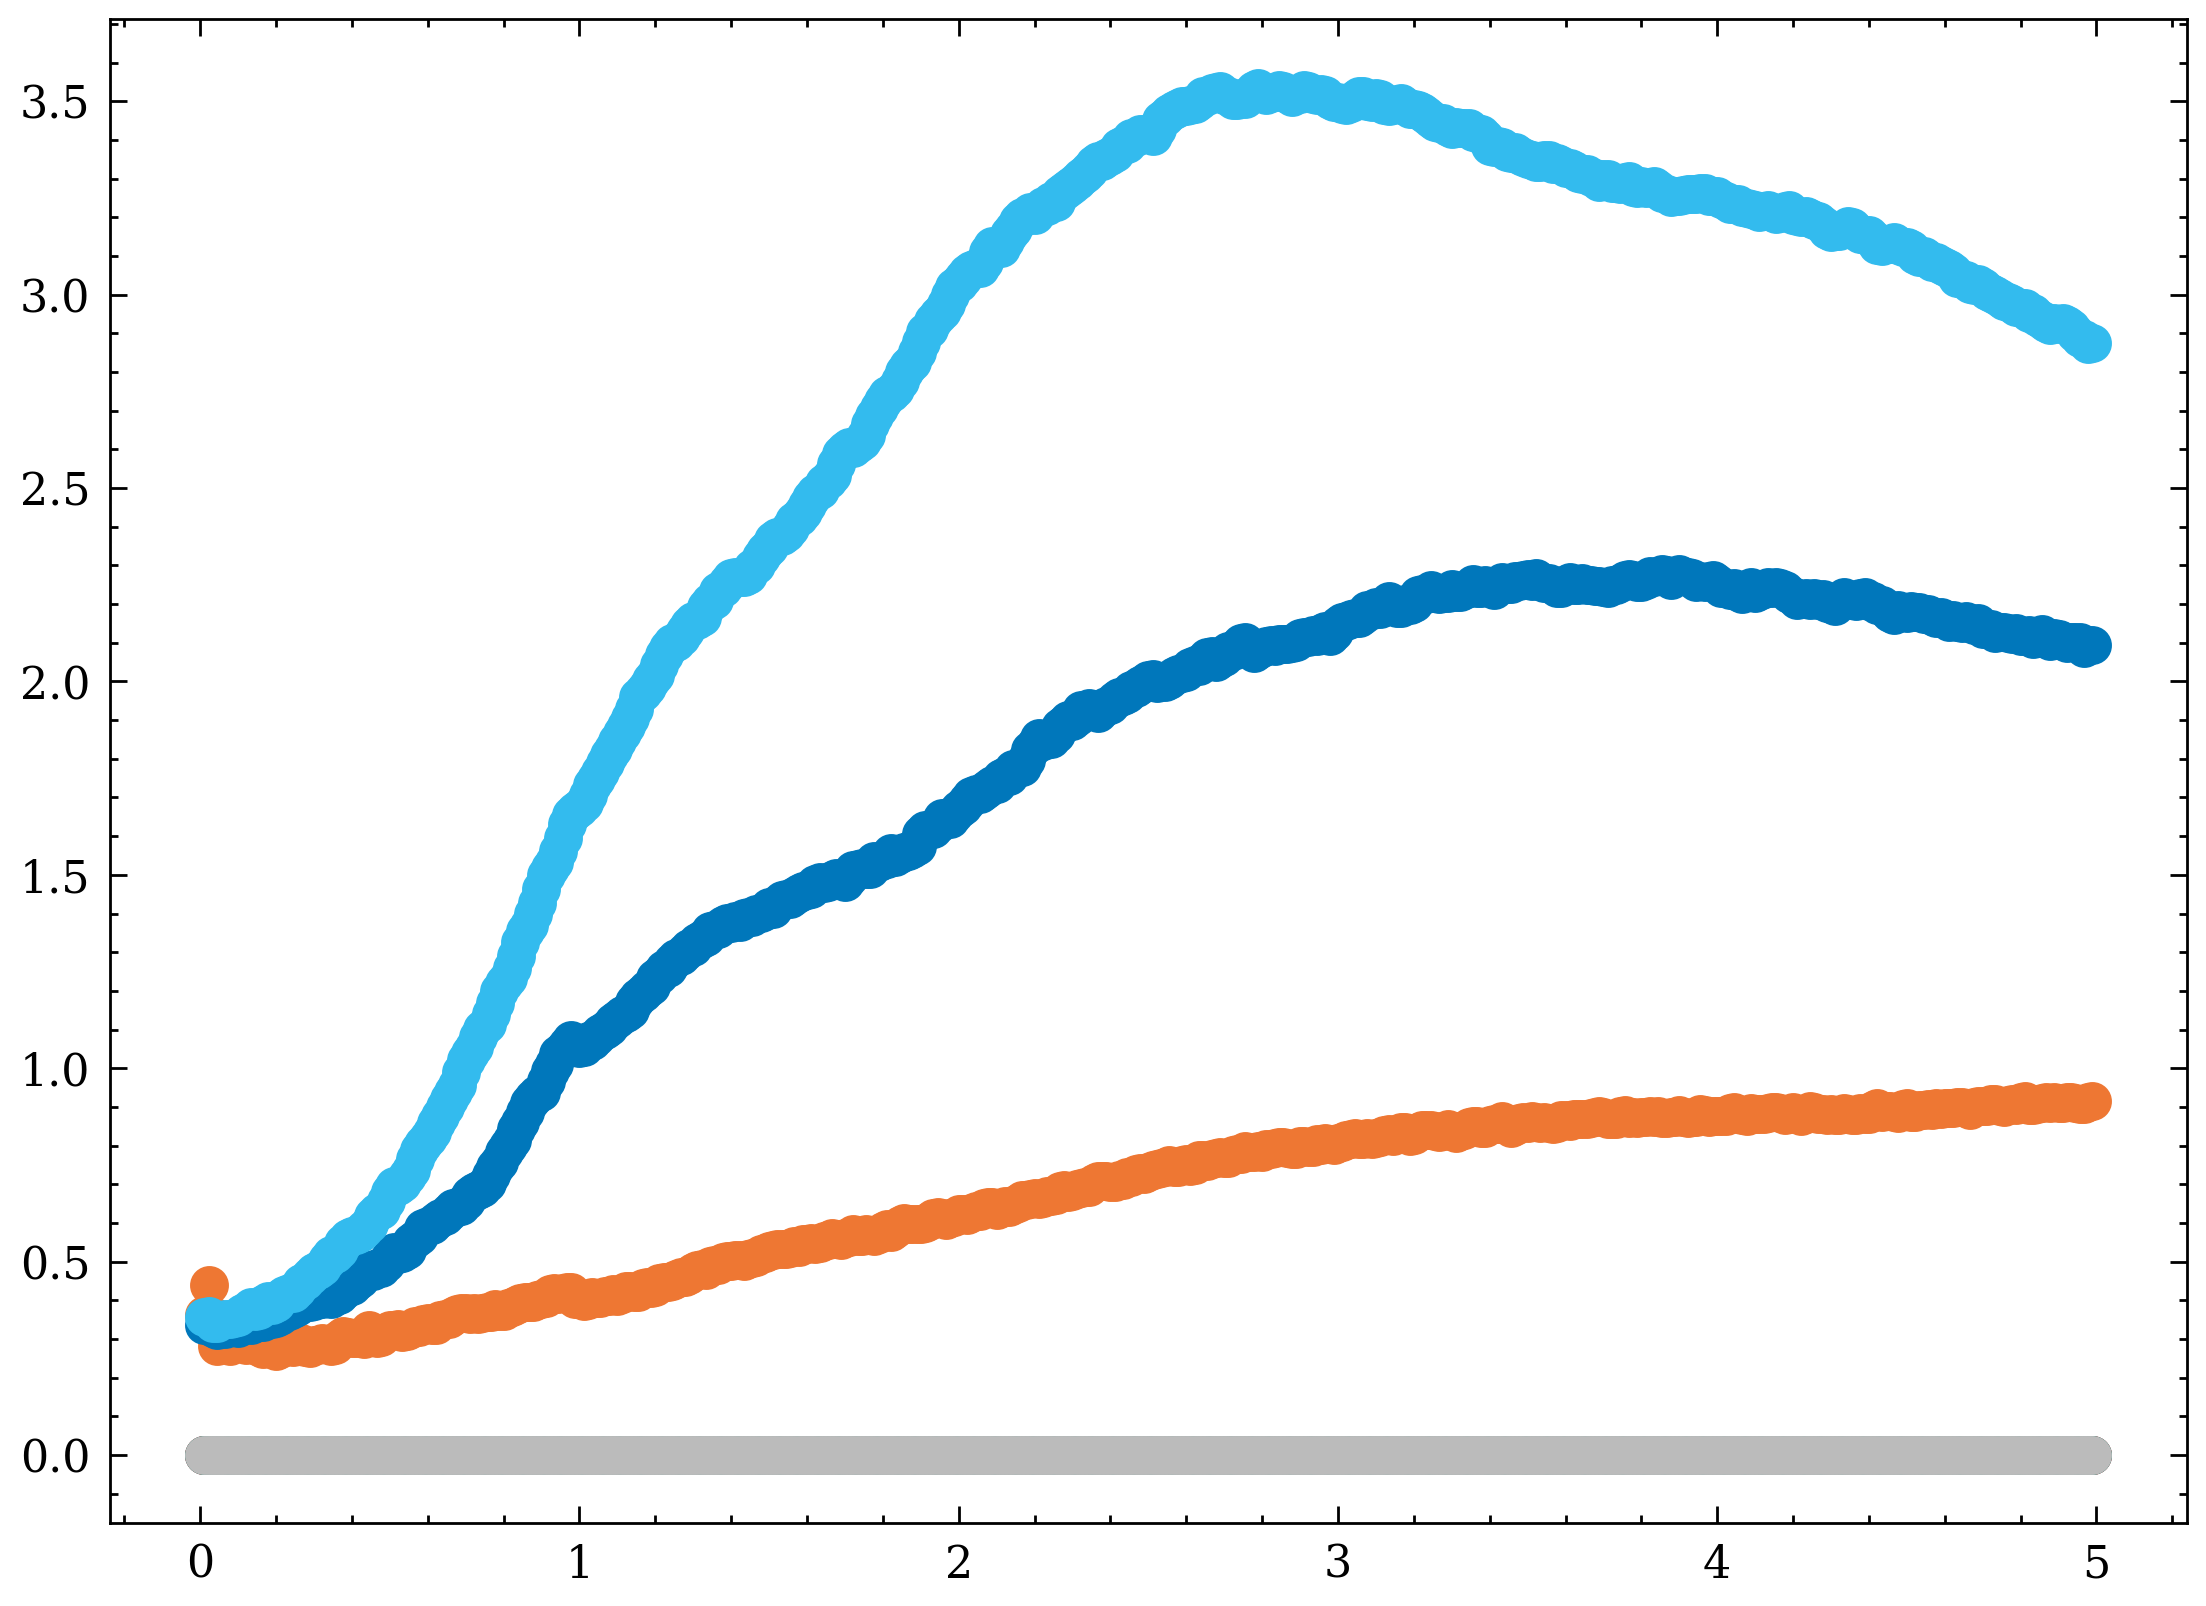

In [14]:
start_frame = 81
end_frame = 530

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4))

for i in range(len(lens)):
    ax.scatter(Time[start_frame:end_frame]-8/9, Circulation[i, start_frame:end_frame], label='{} Length'.format(lens[i]))
    # ax.plot(Circulation[i, start_frame:end_frame], label='{} RPM'.format(rpms[i]))
# ax.plot(sumVorticity5050[:], label='{} RPM'.format(rpms[i]))
# ax.plot(Circulation[:], label='{} RPM'.format(rpms[i]))
ax.set_xlabel(r'$t$ [s]')
ax.set_ylabel(r'$\Gamma$ [cm$^2$/s]')
ax.legend(fontsize=8)
ax.set_ylim(0)
plt.show()

Section to look at the peak $\omega_{z}$ against time as per Verzicco and Gan

In [54]:
# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')

vels = h5file['Narrow']['U50']['L50']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
# u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
# u, v = u/0.1, v/0.1 
# r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
# Time = oj.frames_to_seconds(u, v, 90)
# h5file.close()

Circulation = np.zeros([7, u.shape[0]])
# Circulation = np.zeros([u.shape[0]])
vort = np.zeros([7, u.shape[0], u.shape[1], u.shape[2]])
vort_gauss = np.zeros([7, u.shape[0], u.shape[1], u.shape[2]])

rpms = [0, 1, 2, 3, 6, 9, 12]
# rpms = [6, 9, 12]
for i in range(len(rpms)):
# for i in range(3):

    vels = h5file['Narrow']['U100']['L100']['RPM{}'.format(rpms[i])]
    # vels = h5file['Narrow']['U100']['L100']['RPM0']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90)
    Circulation[i, :] = oj.sum_Vorticity(u[:,:,18:], v[:,:,18:])
    vort[i,:,:,:], vort_gauss[i,:,:,:] = oj.calculate_vorticity(u, v)
    print(rpms[i])

Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

0
1
2
3
6
9
12


C:\Users\u2088308\AppData\Local\Temp\ipykernel_21716\320300646.py:2: RuntimeWarning: divide by zero encountered in divide
  scaling = 1/Time**3


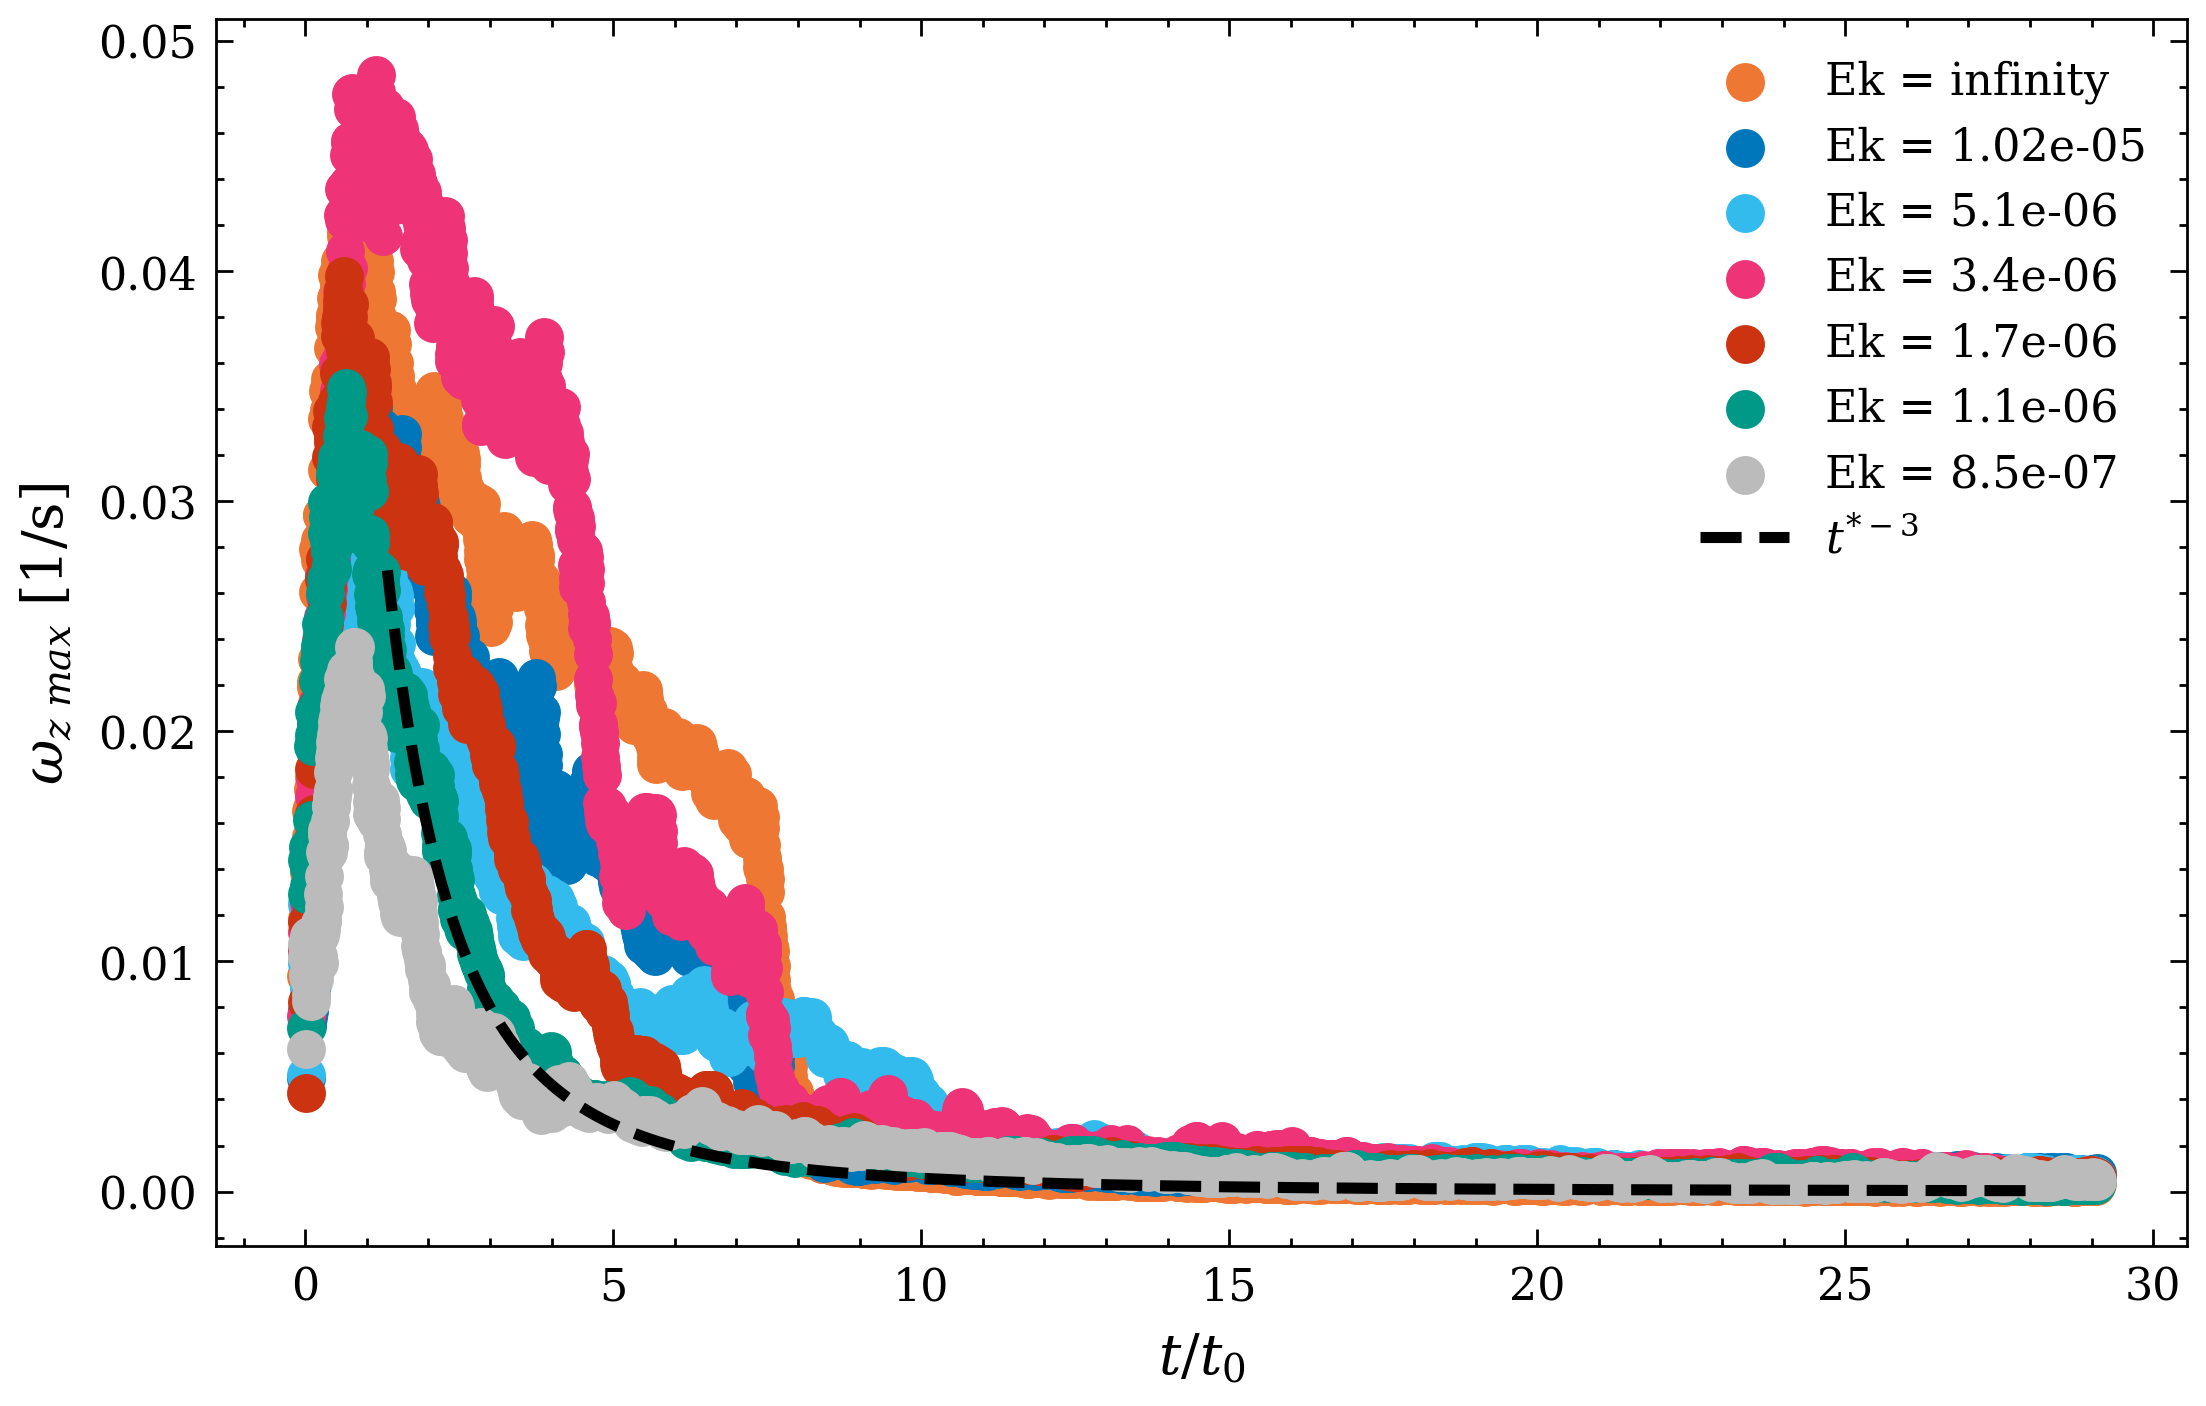

In [55]:
omegaPeak = np.zeros([7, u.shape[0]])
scaling = 1/Time**3

# Eks = [0.0000017, 0.0000011, 0.00000085]
Eks = ['infinity', 0.0000102, 0.0000051, 0.0000034, 0.0000017, 0.0000011, 0.00000085]
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))
for i in range(7):
    for j in range(u.shape[0]):
        omegaPeak[i, j] = np.max(vort[i, j, :, :])
    
    ax.scatter(Time[81:]-8/9, omegaPeak[i, 81:], label='Ek = {}'.format(Eks[i]))
    # ax.plot(Time-8/9, Circulation[i, :], label='{} RPM'.format(rpms[i]))
ax.plot(Time[300:]-2, scaling[300:], label=r'$t^{*-3}$', linestyle='--', color='black')

ax.set_xlabel(r'$t/t_{0}$')
ax.set_ylabel(r'$\omega_{z~max}$ [1/s]')
plt.legend(fontsize=8)

In [39]:
vels = h5file['Narrow']['U50']['L50']['RPM{}'.format(rpms[i])]
# vels = h5file['Narrow']['U100']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
print(u.shape)
edge_r = 119
edge_l = 30 

# svul0  = oj.sum_Vorticity(u[:,20:,:30], v [:,20:,:30]) +  oj.sum_Vorticity( u [:,20:,119:], v [:, 20:, 119:])
svul0  = oj.sum_Vorticity(u[:,:40,45:], v [:,:40,45:]) +  oj.sum_Vorticity( u [:,109:,45:], v[:,109:,45:])



(2699, 149, 239)


0
1
2
3
6
9
12


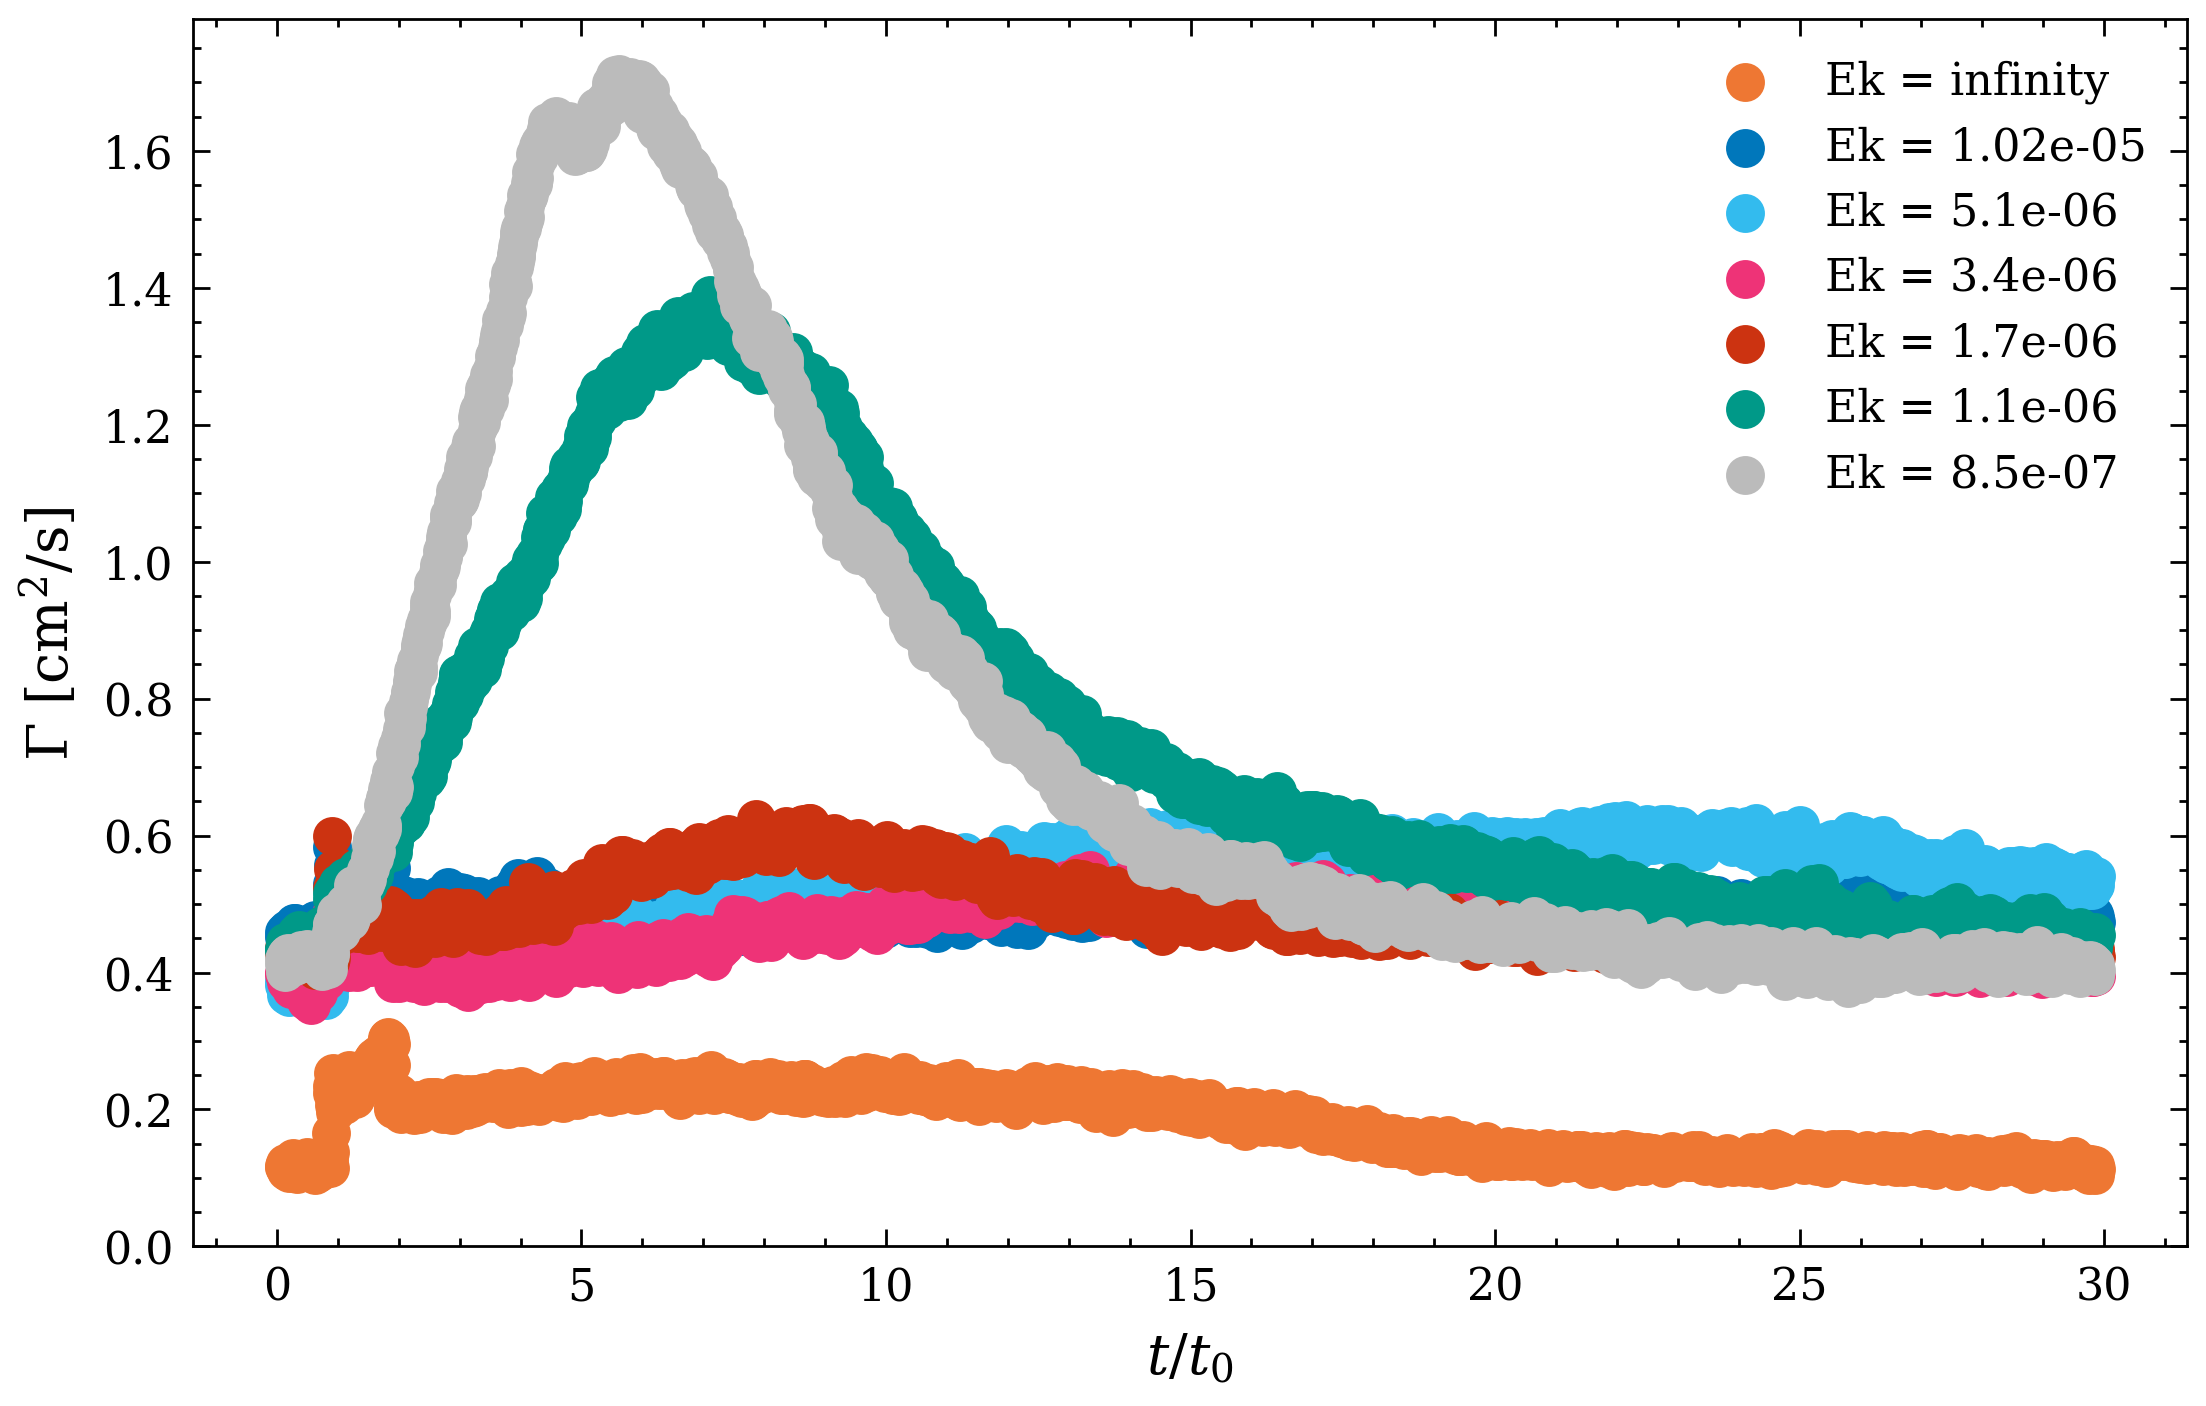

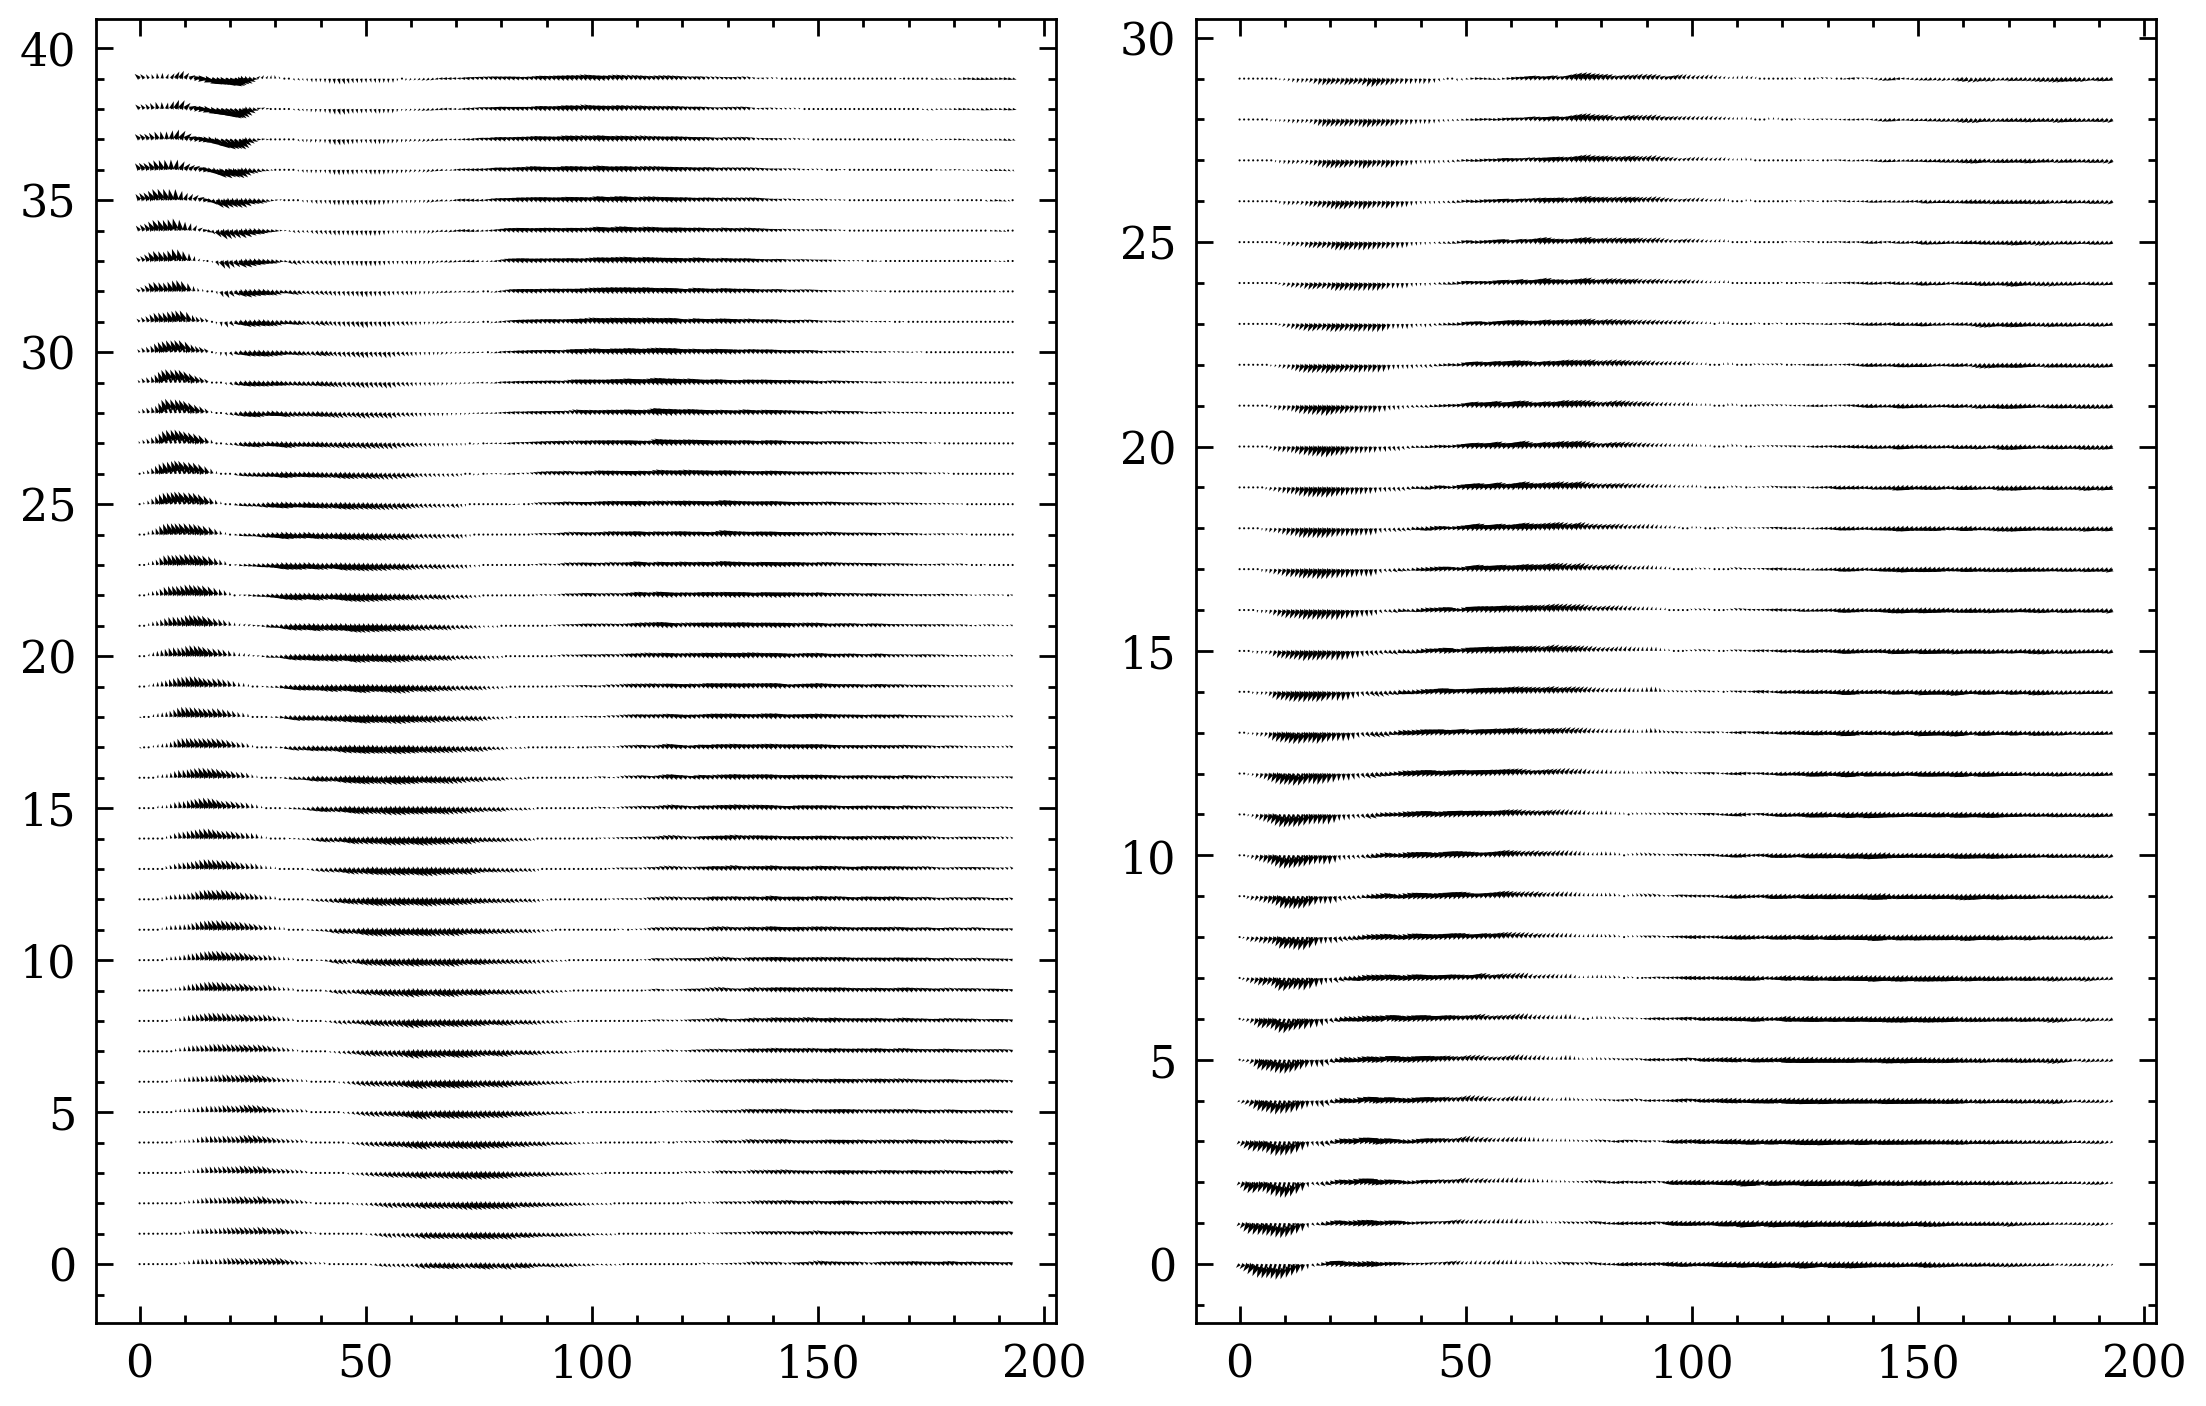

In [47]:
h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
Eks = ['infinity', 0.0000102, 0.0000051, 0.0000034, 0.0000017, 0.0000011, 0.00000085]

fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))
for i in range(7):
    vels = h5file['Narrow']['U50']['L50']['RPM{}'.format(rpms[i])]
    # vels = h5file['Narrow']['U100']['L100']['RPM0']
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90)
    # svul0  = oj.sum_Vorticity(u[:,:40,45:], v [:,:40,45:]) +  oj.sum_Vorticity( u [:,109:,45:], v[:,109:,45:])
    # ax.plot(Time, svul0[:]-0.4 , label = "Ek = {}".format(Eks[i]))
    svul0  = oj.sum_Vorticity(u[:,:30,45:], v [:,:30,45:]) +  oj.sum_Vorticity( u [:,119:,45:], v[:,119:,45:])
    ax.scatter(Time[10:-10], svul0[10:-10]-0.3 , label = "Ek = {}".format(Eks[i]))
    print(rpms[i])

ax.set_xlabel(r"$t/t_{0}$")
ax.set_ylabel('$\Gamma$ [cm$^2$/s]')
# plt.title("Circulation at large r 50/50")
ax.set_ylim(0)
plt.legend(fontsize=8)

fig2, (ax2, ax3) = plt.subplots(1, 2, figsize=(5.5, 3.5))
ax2.quiver(u[500,:40,45:], v[500,:40,45:])
ax3.quiver(u[500,119:,45:], v[500,119:,45:])

plotting peak $\omega$ for rings with the same Ro

C:\Users\u2088308\AppData\Local\Temp\ipykernel_21716\1660244482.py:27: RuntimeWarning: divide by zero encountered in divide
  scaling = 1/Time**2


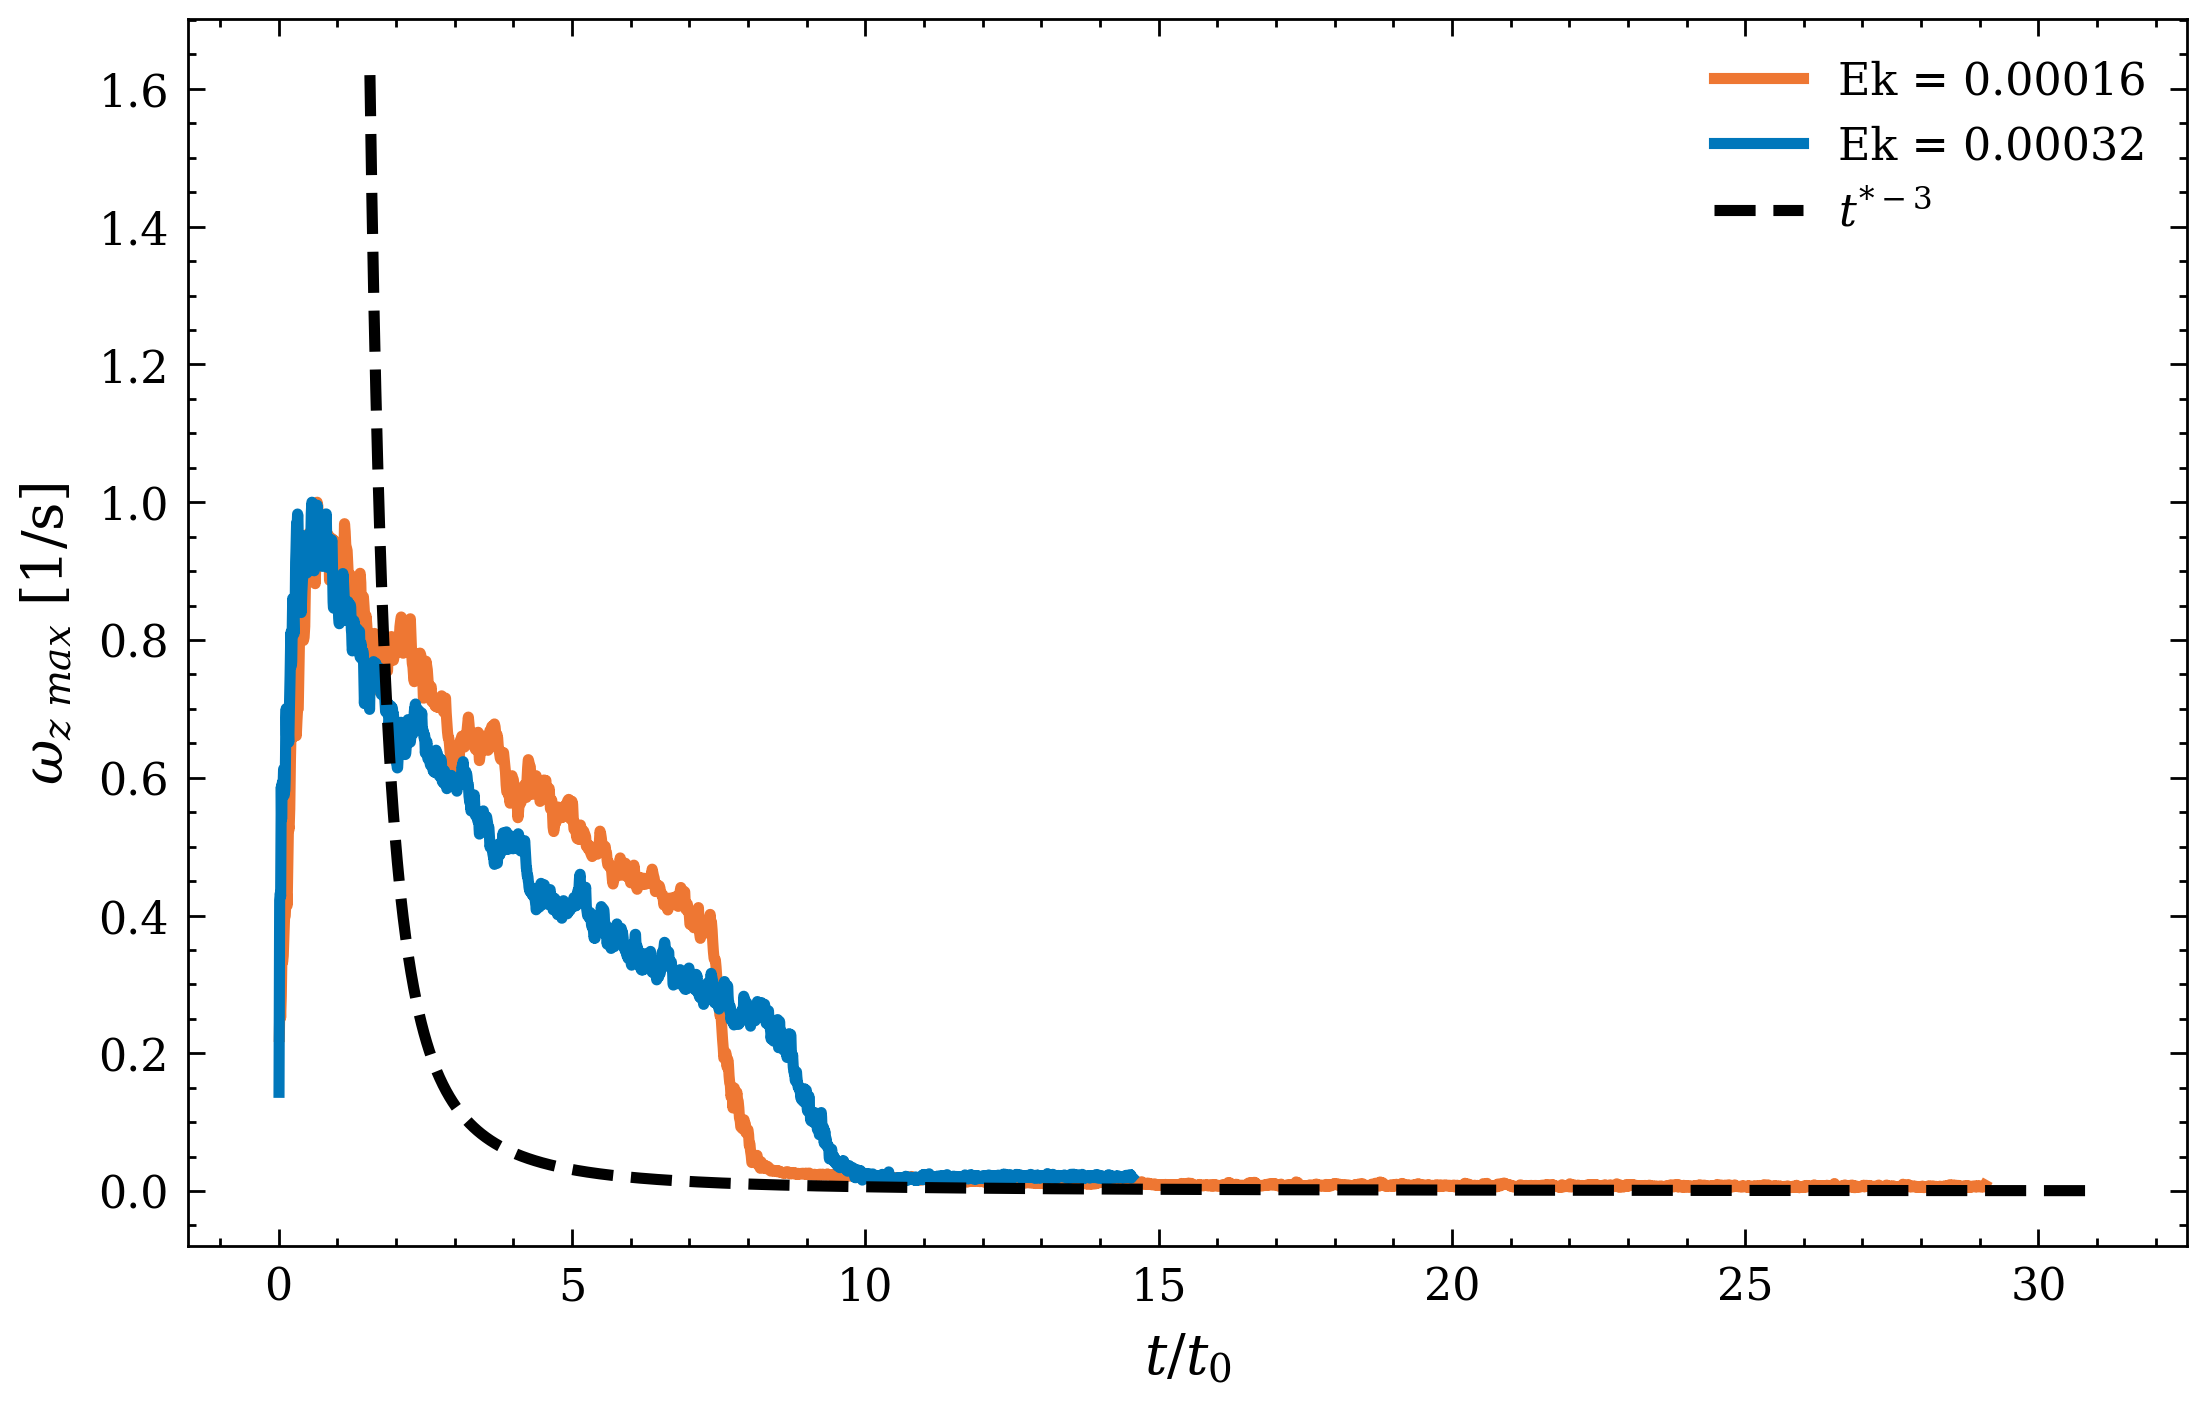

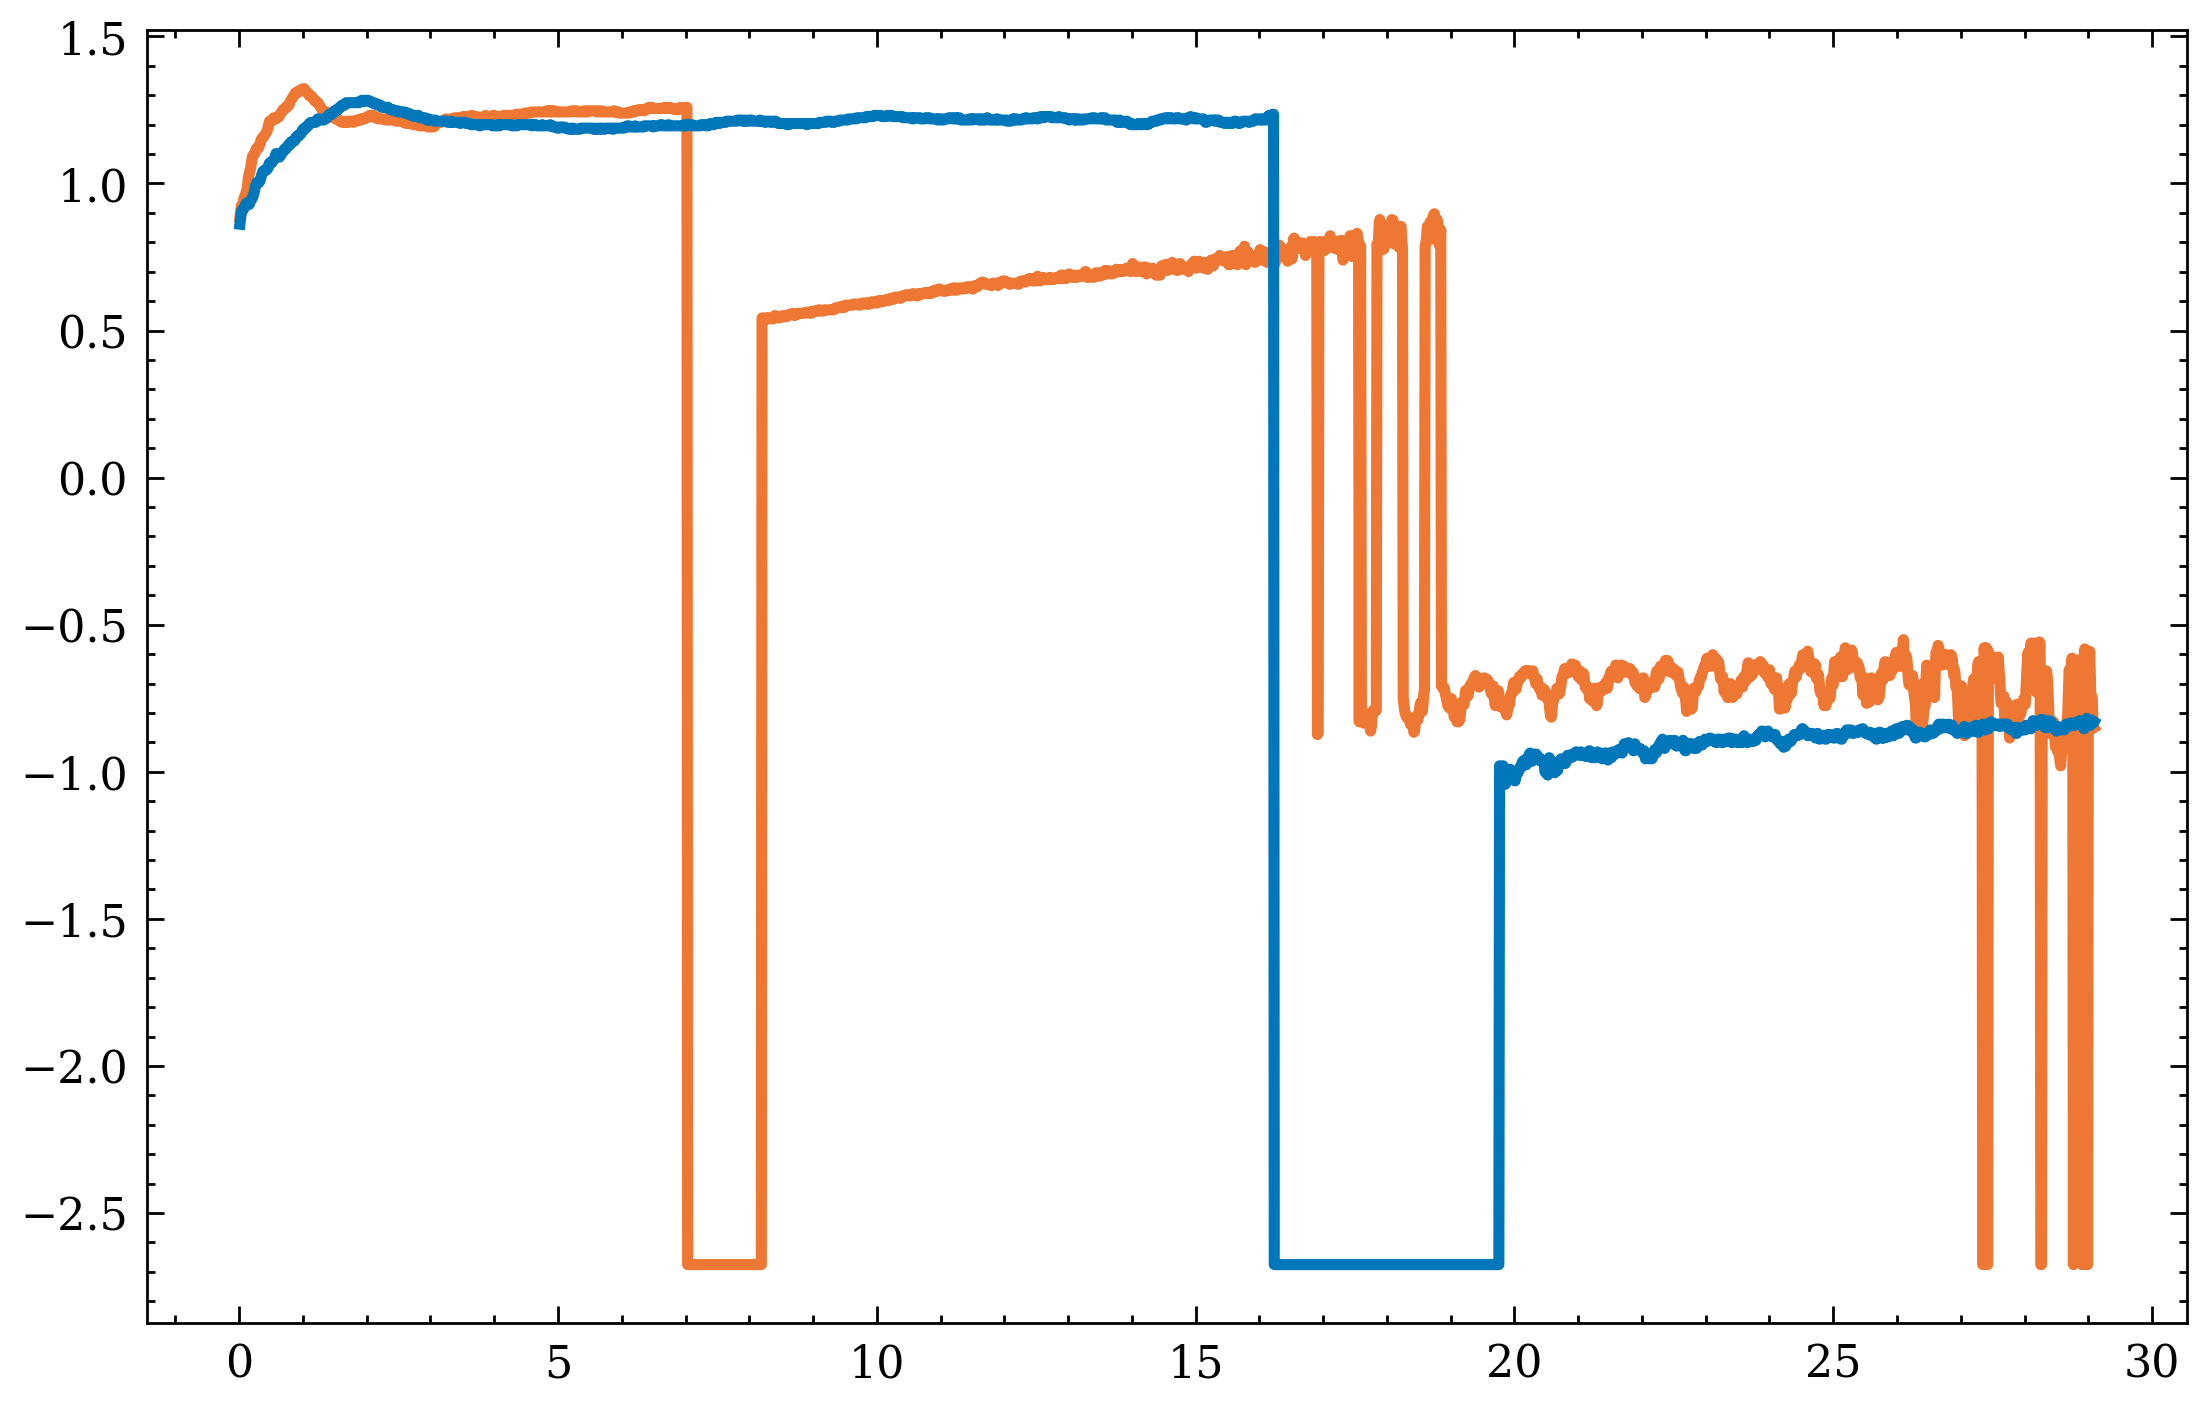

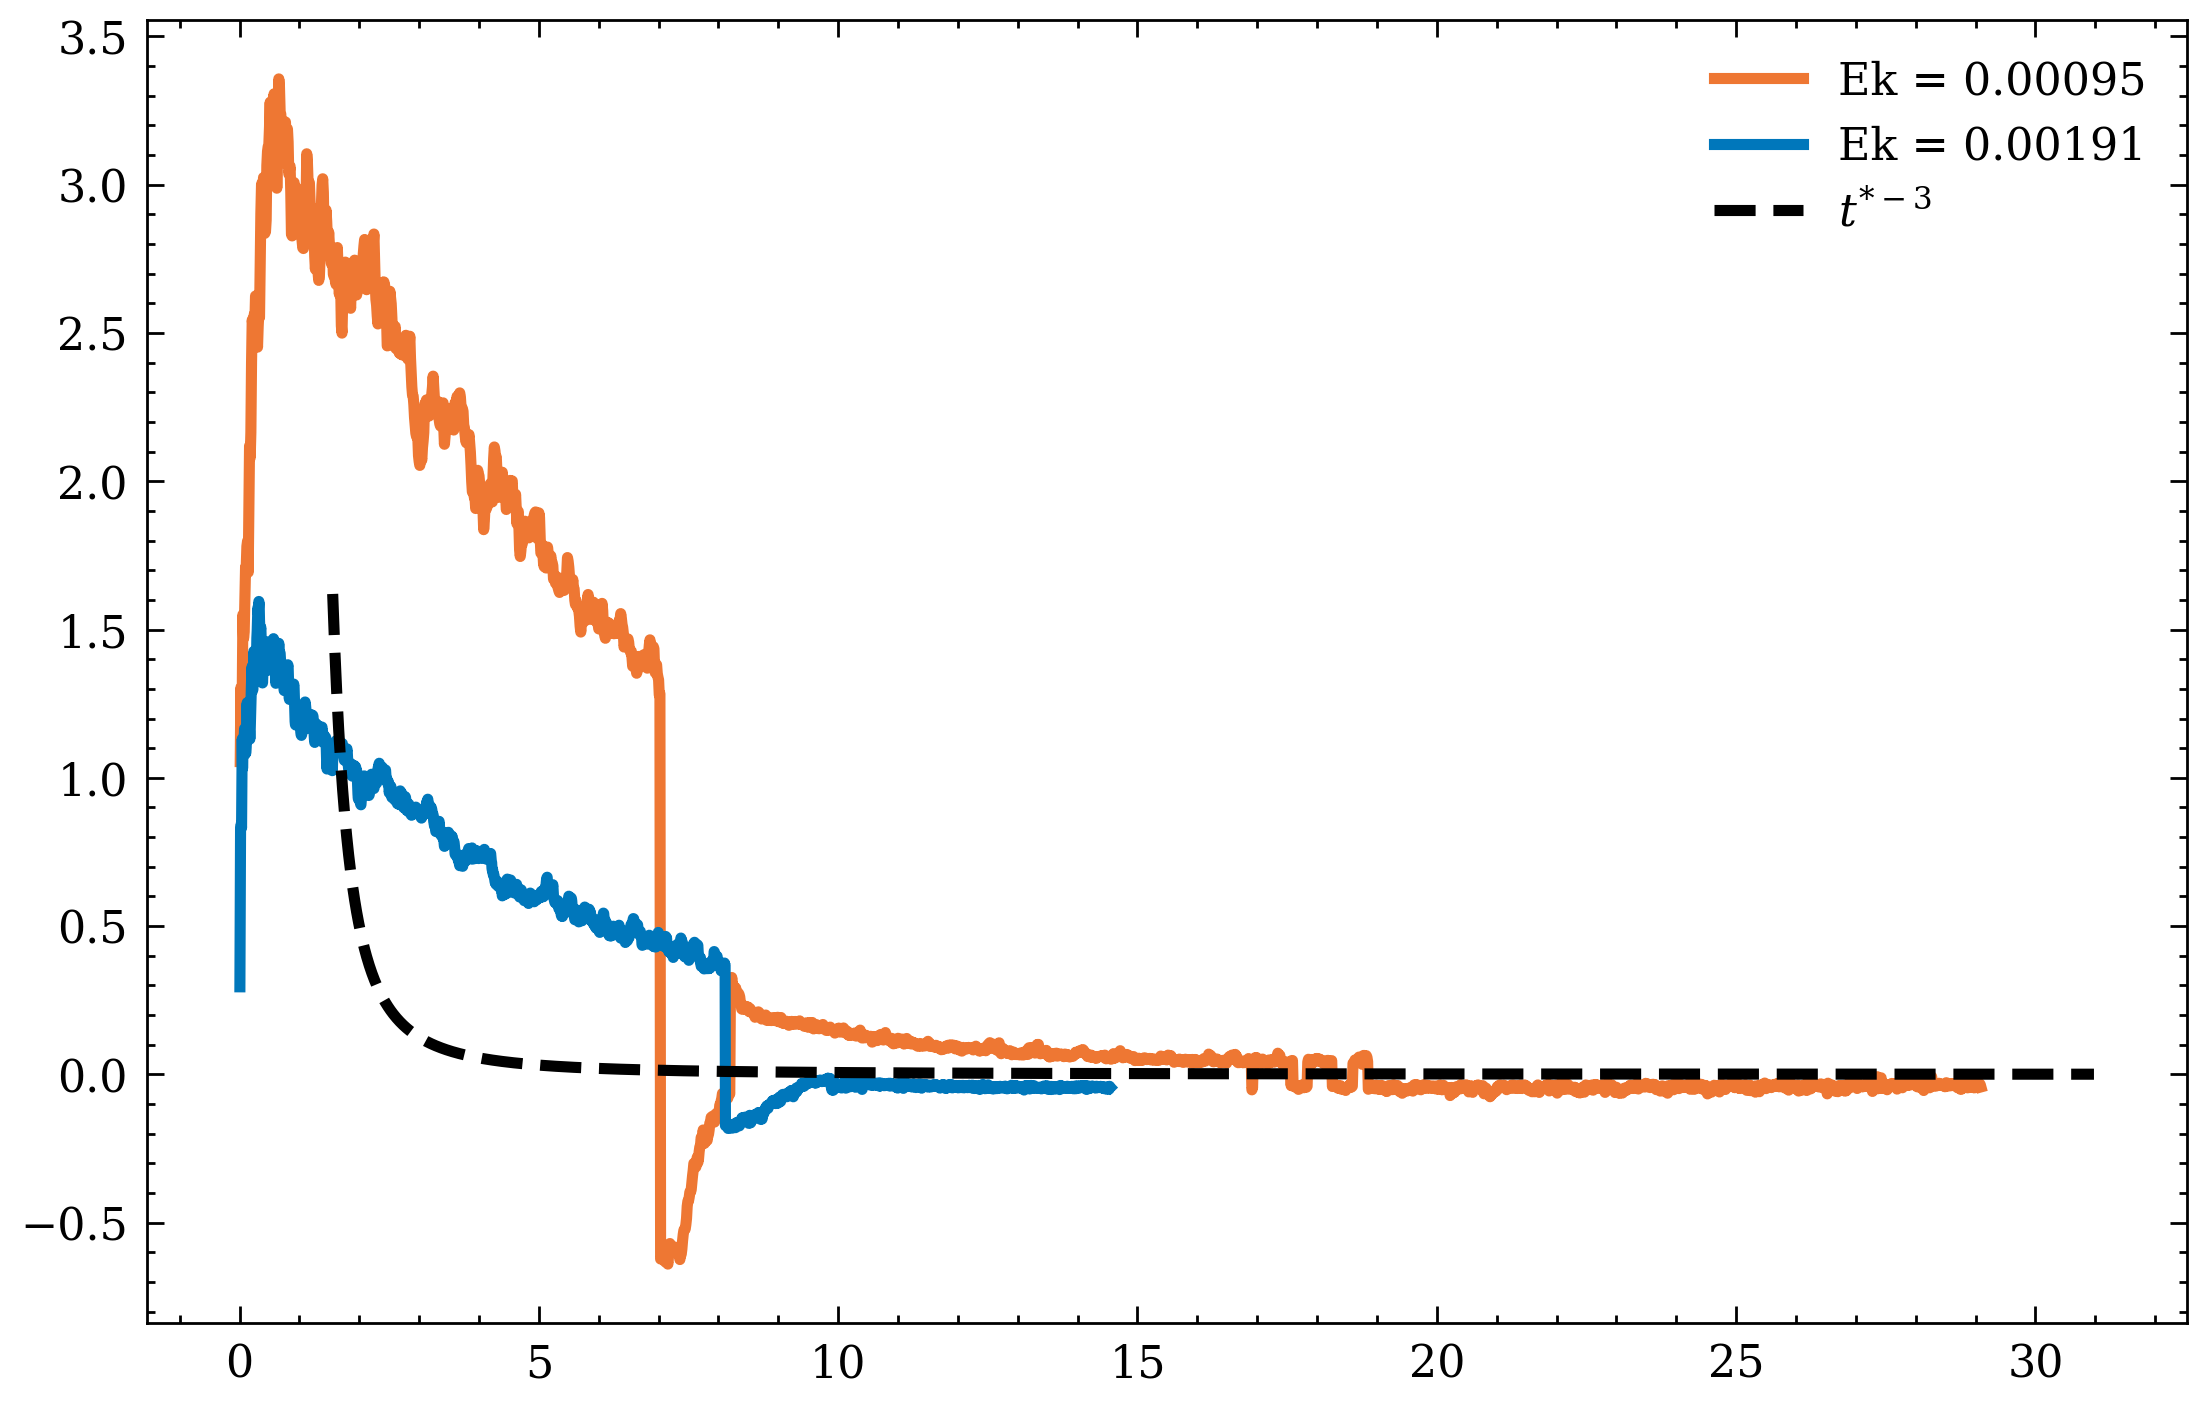

In [115]:
# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
vels = h5file['Narrow']['U100']['L100']['RPM0']
# vels = h5file['Narrow']['U100']['L100']['RPM0']
u1 = vels[:,:,:,0]
v1 = vels[:,:,:,1] 
vort1, vort_gauss1 = oj.calculate_vorticity(u1, v1)
VortLocMax1, VortLocMin1 = oj.vorticityPeakTracking_inter(u1[:,:,:], v1[:,:,:])
VortLocMin1[:,0] = np.subtract(VortLocMin1[:,0], int(u.shape[1]/2))
VortLocMax1[:,0] = np.subtract(VortLocMax1[:,0], int(u.shape[1]/2))
r_factor = u.shape[1]/(2*r_nd[-1])
VortLocMax1[:,1], VortLocMax1[:,0] = VortLocMax1[:,1]/r_factor-1, VortLocMax1[:,0]/r_factor

vels = h5file['Narrow']['U50']['L100']['RPM0']
# vels = h5file['Narrow']['U100']['L100']['RPM0']
u2 = vels[:,:,:,0]
v2 = vels[:,:,:,1] 
vort2, vort_gauss2 = oj.calculate_vorticity(u2, v2)
vort1, vort_gauss1 = oj.calculate_vorticity(u1, v1)
VortLocMax2, VortLocMin2 = oj.vorticityPeakTracking_inter(u2[:,:,:], v2[:,:,:])
VortLocMin2[:,0] = np.subtract(VortLocMin2[:,0], int(u.shape[1]/2))
VortLocMax2[:,0] = np.subtract(VortLocMax2[:,0], int(u.shape[1]/2))
VortLocMax2[:,1], VortLocMax2[:,0] = VortLocMax2[:,1]/r_factor-1, VortLocMax2[:,0]/r_factor

omegaPeak1 = np.zeros([u.shape[0]])
omegaPeak2 = np.zeros([u.shape[0]])
scaling = 1/Time**2

for i in range(u.shape[0]):
    omegaPeak1[i] = np.max(vort1[i,:, :])
    omegaPeak2[i] = np.max(vort2[i,:, :])


fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))
ax.plot(Time[81:]-8/9, omegaPeak1[81:]/np.max(omegaPeak1), label='Ek = {}'.format(round(oj.Ek(12), 5)))
ax.plot((Time[81:]-8/9)/2, omegaPeak2[81:]/np.max(omegaPeak2), label='Ek = {}'.format(round(oj.Ek(6), 5)))
ax.plot(Time[50:]+1, scaling[50:]*0.5, label=r'$t^{*-3}$', linestyle='--', color='black')

ax.set_xlabel(r'$t/t_{0}$')
ax.set_ylabel(r'$\omega_{z~max}$ [1/s]')
plt.legend(fontsize=8)

f2, ax2 = plt.subplots(1, 1, figsize=(5.5, 3.5))
ax2.plot(Time[81:]-8/9, VortLocMax1[81:,0], label='Max Vorticity 1')
ax2.plot(Time[81:]-8/9, VortLocMax2[81:,0], label='Max Vorticity 2')

f3, ax3 = plt.subplots(1, 1, figsize=(5.5, 3.5))
ax3.plot( Time[81:]-8/9,    omegaPeak1[81:]/VortLocMax1[81:, 0], label='Ek = {}'.format(round(oj.Ek(2), 5)))
ax3.plot((Time[81:]-8/9)/2, omegaPeak2[81:]/VortLocMax2[81:, 0], label='Ek = {}'.format(round(oj.Ek(1), 5)))
ax3.plot(Time[50:]+1, scaling[50:]*0.5, label=r'$t^{*-3}$', linestyle='--', color='black')
plt.legend(fontsize=8)